# Experiment 3: Frequency Domain Analysis via Fast Fourier Transform (FFT)

Reflections and background transmission layers typically exhibit vastly different properties in the frequency domain. 
* **Backgrounds (Transmission):** Usually in sharp focus, containing high-frequency structural details (sharp edges, hard textures).
* **Reflections:** Often out-of-focus, blurry, or semi-transparent, dominating the low-to-mid frequency spectrum.

By transforming our spatial images into the frequency domain using a 2D Discrete Fourier Transform (DFT), we can analyze how effectively the neural network separates these frequencies.

### Mathematical Formulation
The 2D DFT of an image $f(x,y)$ of size $M \times N$ is defined as:
$$F(u, v) = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} f(x, y) e^{-i 2\pi (\frac{ux}{M} + \frac{vy}{N})}$$

Because the dynamic range of the Fourier coefficients is massive, we visualize the **Magnitude Spectrum** on a logarithmic scale:
$$S(u,v) = \log(1 + |F(u,v)|)$$

In [1]:
import os, sys
import glob
import random

sys.path.append(os.path.abspath('..'))

from analysis_modules.fft_viz import analyze_frequency_domain
from analysis_modules.residual_viz import analyze_amplified_differences

# Define Paths
base_path = '/storage/hdd1/data/amanr.mds2024/robustsirr_test_dataset/'
output_path = './results/all_datasets_eval/'

dataset_name = 'OpenRR100'
rel_path = 'OpenRR100'

# Directories
in_dir = os.path.join(base_path, rel_path, 'blended')
gt_dir = os.path.join(base_path, rel_path, 'transmission_layer')
out_img_dir = os.path.join(output_path, dataset_name, 'Real-img')

# Pick a specific processed output
out_files = sorted(glob.glob(os.path.join(out_img_dir, '*.png')))
selected_out = out_files[2] if len(out_files) > 2 else out_files[0]
base_name = os.path.splitext(os.path.basename(selected_out))[0]

# Resolve paths
path_I = glob.glob(os.path.join(in_dir, f"{base_name}.*"))[0]
path_T = glob.glob(os.path.join(gt_dir, f"{base_name}.*"))[0]
path_T_hat = selected_out

print(f"Target Image: {os.path.basename(path_I)}")

Target Image: test_0003.jpg


### 1. Magnitude Spectrum Comparison

**What to look for:**
1. **Input Spectrum:** Will contain overlapping directional spikes representing both the background edges and the reflection edges.
2. **Output Spectrum:** If the model successfully removed the reflection, the frequency spikes corresponding to the reflection's gradients should vanish, leaving a spectrum that closely matches the Ground Truth.
3. **Over-smoothing:** If the Output spectrum looks "dimmer" or is missing high-frequency edges at the outer perimeter compared to the Ground Truth, it means the neural network over-blurred the image while trying to erase the reflection.

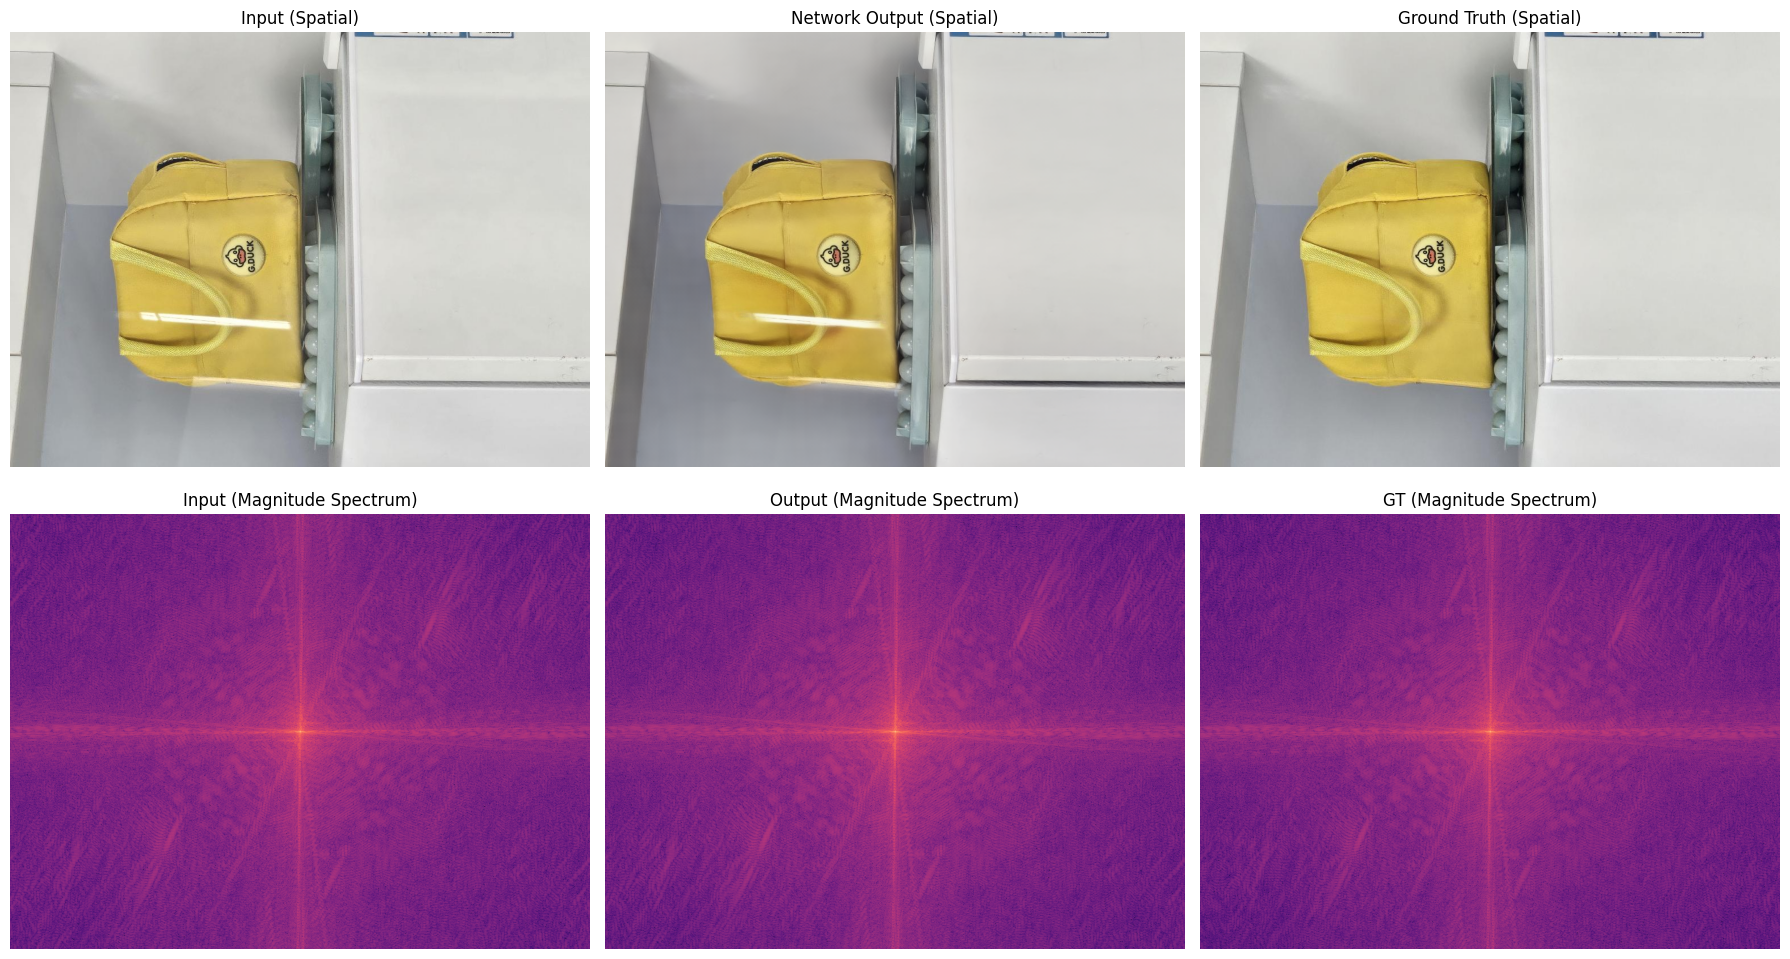

In [2]:
# Analyze frequency domain
analyze_frequency_domain(path_I, path_T, path_T_hat)

### 2. Amplified Residual Analysis

To verify that the structural semantics of the reflection have been completely eradicated, we compute the absolute difference between the model's output and the ground truth, and scale the pixel intensities up (e.g., $8\times$). 

This forces any "ghosting" artifacts left behind by the network to become better visible in the `turbo` heatmap.

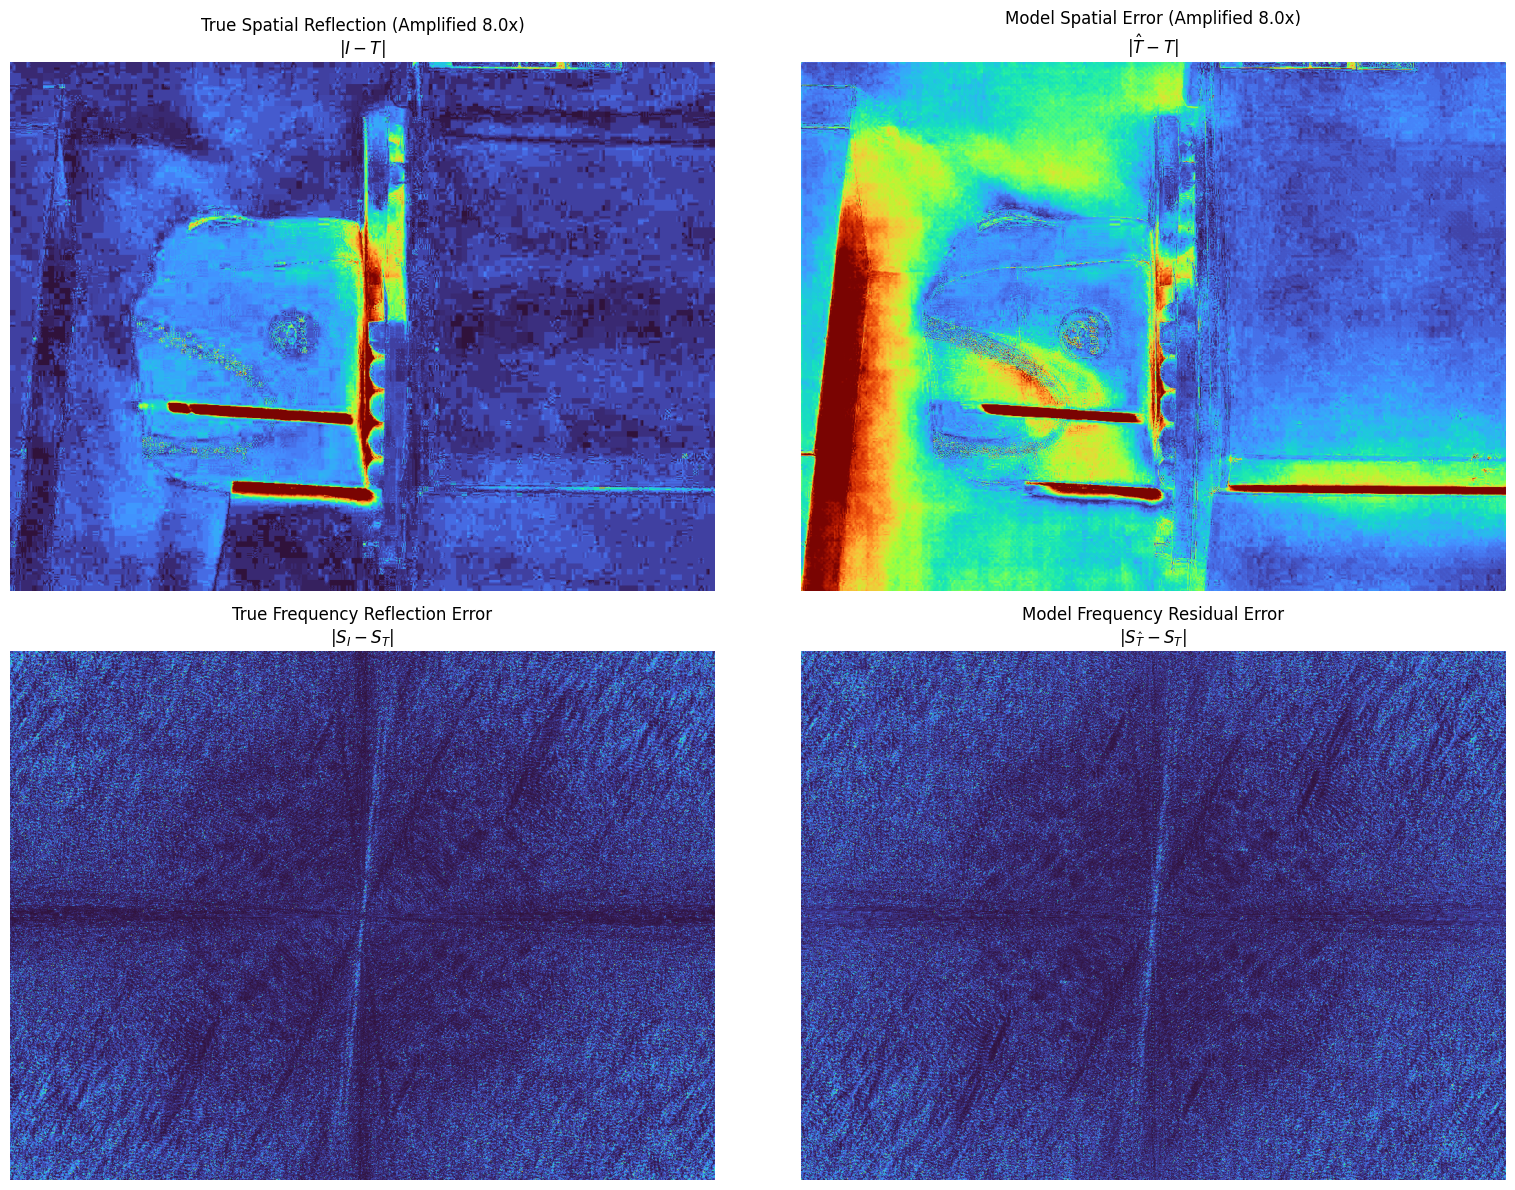

In [3]:
# Analyze amplified differences
analyze_amplified_differences(path_I, path_T, path_T_hat, scale_factor=8.0)

### Interpretation of the Amplified Residuals

By amplifying the differences by $8.0\times$, we force the model's subtle mistakes to become glaringly obvious.

* **Top-Left ($|I - T|$): The True Reflection ($R$)**
    This shows the exact physical reflection that was polluting the image. We see a strong vertical glare on the far left (the bright red/yellow bar) and the faint outlines of some structural reflection artifacts overlapping the yellow duck bag.
* **Top-Right ($|\hat{T} - T|$): The Model's Mistakes**
    If the model were perfect, this quadrant would be completely dark blue. Instead, we see two massive issues:
    1.  **The Red Vertical Smear:** The model completely failed to erase the strong glare on the left. In fact, the bright red indicates it likely introduced a color shift or left a massive artifact behind. 
    2.  **Ghosting Around Edges:** You can see the bright structural outline of the bag and the plastic tray. This indicates the model "over-smoothed" the image—it damaged the sharp edges of the *true* transmission layer while trying to scrub out the reflection.
* **Bottom-Left ($|S_I - S_T|$): True Frequency Disturbance**
    This shows the frequency footprint of the reflection itself. The faint diagonal streaks represent the directional edges and light shifts caused by the glass glare.
* **Bottom-Right ($|S_{\hat{T}} - S_T|$): Residual Frequency Error**
    Because we still see distinct structural streaks here (it is not purely random noise), it confirms that the network failed to filter out the specific frequency bands associated with the reflection. It left high-frequency "ghosts" behind.

---